# Assignment 1: Opinion Network Formation

In this notebook, we are constructing a respondent-based network from the survey dataset, `Survey_Results_UC.csv`[cite: 1]. Conceptually, this process shares the same underlying logic used when mapping structural connectomes or calculating distance metrics for a k-nearest neighbors classifier: we are transforming behavioral data into a multidimensional feature space to identify structural clusters. 

Here, each respondent serves as a distinct node, and the edges will be determined by the mathematical similarity of their survey answers across the four domains (Technology, Education, Ethics, Environment)[cite: 1].

### Step 1: Vectorization and Data Preprocessing
The raw data consists of text-based Likert-scale responses. Before we can compute a similarity matrix or isolate sub-graphs, we must encode these string values into a continuous numerical format. 

In the execution block below, we will:
1. Load `Survey_Results_UC.csv` into a pandas DataFrame.
2. Construct a mapping dictionary to convert ordinal text (e.g., "Strongly Disagree" to "Strongly Agree") into integer values (1 through 5). We handle edge cases like "No Comments" by imputing a neutral weight (3) to prevent matrix sparsity.
3. Separate the numerical feature matrix from the respondent IDs to prepare for the cosine similarity operations in the next step.

In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Survey_Results_UC.csv')

# 2. Define the Likert scale mapping dictionary
likert_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5,
    'No Comments': 3 
}

# 3. Apply the mapping to all survey columns
# The first column is 'id. Response ID', so we isolate the question columns
survey_cols = df.columns[1:]
df_numeric = df.copy()

for col in survey_cols:
    df_numeric[col] = df_numeric[col].map(likert_mapping)

# Check for any remaining NaNs that might have been caused by unexpected text
if df_numeric[survey_cols].isna().sum().sum() > 0:
    print("Warning: Missing values detected. Filling with neutral score (3).")
    df_numeric[survey_cols] = df_numeric[survey_cols].fillna(3)

# 4. Extract the final feature matrix for network construction
features = df_numeric[survey_cols].values
respondent_ids = df_numeric['id. Response ID'].values

# Sanity check the resulting matrix
print(f"Successfully vectorized data for {features.shape[0]} respondents across {features.shape[1]} questions.")
display(df_numeric.head())

Successfully vectorized data for 96 respondents across 60 questions.


,id. Response ID,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.,T07. Robots should replace humans in hazardous occupations whenever possible.,T08. AI-assisted diagnosis should become routine in healthcare.,T09. Autonomous vehicles will ultimately make transportation safer.,...,"V06. Water conservation should be a priority in households, institutions, and industries.",V07. Protecting biodiversity is essential for long-term human well-being.,V08. Universities should adopt environmentally sustainable campus practices even if implementation costs increase.,"V09. Products should be designed to encourage reuse, repair, and recycling.",V10. Consumers should consider environmental impact when purchasing products.,V11. Technological innovation is essential for addressing environmental challenges.,V12. Environmental sustainability should be integrated into higher education curricula.,V13. Companies should be held accountable for the environmental impacts of their activities.,V14. International cooperation is necessary to effectively address environmental challenges.,V15. Current generations have a responsibility to protect natural resources for future generations.
0,11,4.0,4.0,3.0,5.0,5.0,4.0,4.0,2.0,3.0,...,3.0,4.0,3.0,5.0,3.0,3.0,3.0,4.0,4.0,3.0
1,12,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,...,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0
2,13,4.0,5.0,3.0,2.0,5.0,4.0,5.0,4.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,4.0
3,14,3.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0
4,16,3.0,4.0,5.0,5.0,1.0,5.0,5.0,4.0,3.0,...,4.0,5.0,4.0,5.0,3.0,4.0,3.0,5.0,5.0,4.0


### Step 2: Similarity Matrix and Edge Formation

To transform isolated survey rows into a structured network, we must quantify the ideological distance between every pair of respondents. Just as distance metrics define proximity in a k-nearest neighbors classifier, we use mean-centered Cosine Similarity (which is mathematically equivalent to the Pearson correlation coefficient) to establish our edges. 

We apply mean-centering because raw Likert scores range from 1 to 5, meaning all vectors sit in the positive mathematical space. If we simply calculated the uncentered cosine similarity, a respondent who answered "Strongly Disagree" (1s) to everything and a respondent who answered "Strongly Agree" (5s) to everything would still register a high positive similarity, as their vectors point in the same general direction. By subtracting each respondent's mean score from their answers, "Disagree" and "Agree" become diametrically opposed vectors (negative and positive values). 

The similarity between respondent $i$ and respondent $j$ is calculated as:

$$S_{ij} = \frac{(\mathbf{v}_i - \bar{v}_i) \cdot (\mathbf{v}_j - \bar{v}_j)}{\|\mathbf{v}_i - \bar{v}_i\| \|\mathbf{v}_j - \bar{v}_j\|}$$

Structurally, this methodology mirrors the construction of functional connectomes in network neuroscience, where edges are formed by thresholding the correlation strength between regional signals. We apply a threshold $\tau$ to the resulting similarity matrix to filter out weak, noisy correlations. Only pairs of respondents with a similarity score $S_{ij} > \tau$ will be connected by an undirected edge in the final adjacency matrix.

Matplotlib is building the font cache; this may take a moment.


Network built with 86 nodes and 893 edges (Threshold: 0.4).
Removed 10 isolated respondents.


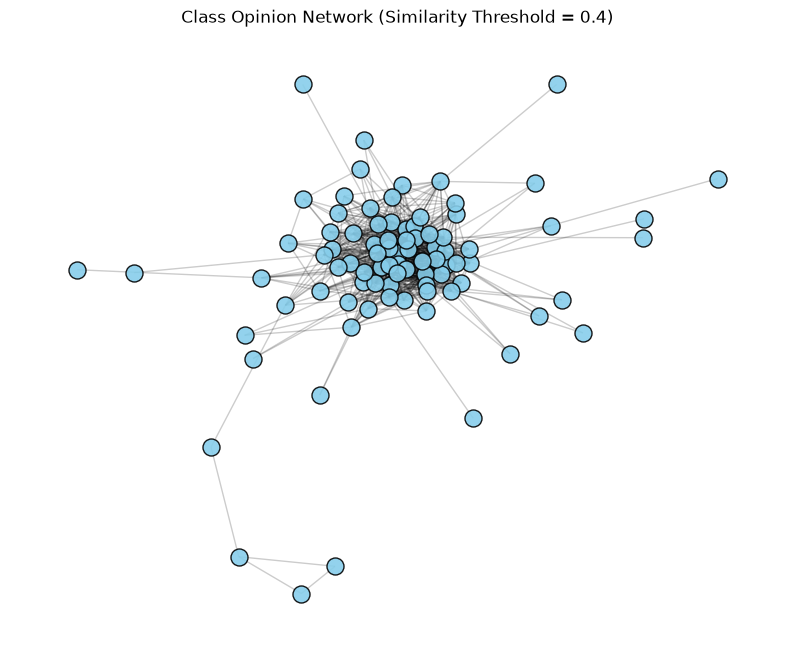

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt

# 1. Mean-Center the Features
# We subtract the mean of each respondent's row to center their opinions around 0
row_means = features.mean(axis=1, keepdims=True)
features_centered = features - row_means

# 2. Compute the Similarity Matrix
# This calculates the cosine similarity (equivalent to Pearson correlation here) between all respondents
sim_matrix = cosine_similarity(features_centered)

# Remove self-loops (a respondent's similarity to themselves is 1.0, but we don't want self-edges)
np.fill_diagonal(sim_matrix, 0)

# 3. Define Threshold and Create Adjacency Matrix
# Through initial exploration, the mean similarity is ~0.20. 
# A threshold of 0.4 captures strong alignments without oversaturating the graph.
tau = 0.40 
adj_matrix = (sim_matrix >= tau).astype(int)

# 4. Construct the Graph
G = nx.from_numpy_array(adj_matrix)

# Map the integer nodes back to the actual Respondent IDs for accurate tracking
node_mapping = {i: respondent_ids[i] for i in range(len(respondent_ids))}
G = nx.relabel_nodes(G, node_mapping)

# Remove completely isolated nodes (respondents who share no strong similarity with anyone)
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

print(f"Network built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges (Threshold: {tau}).")
print(f"Removed {len(isolated_nodes)} isolated respondents.")

# 5. Basic Visualization Preview
plt.figure(figsize=(10, 8))
# spring_layout uses an anti-gravity algorithm to push disconnected nodes apart and pull connected ones together
pos = nx.spring_layout(G, k=0.3, seed=42) 

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=150, alpha=0.9, edgecolors='black')
nx.draw_networkx_edges(G, pos, alpha=0.2)

plt.title(f"Class Opinion Network (Similarity Threshold = {tau})")
plt.axis('off')
plt.show()